# CNN Scene Classification with PyTorch

## Goal

The goal of this notebook is to build a Convolutional Neural Network using PyTorch to classify natural scene images.

The dataset contains images from six scene categories:

- Buildings
- Forest
- Glacier
- Mountain
- Sea
- Street

This project focuses on the full deep learning workflow:

- Loading image data from folders
- Applying image transforms and augmentation
- Building a custom CNN architecture
- Training with PyTorch
- Tracking train and validation loss
- Evaluating accuracy and class-level performance
- Inspecting misclassified images
- Comparing a simple CNN with a slightly improved CNN

In [1]:
import os
import random
import warnings
from pathlib import Path

import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

warnings.filterwarnings("ignore")

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

c:\Users\ADMIN\AppData\Local\Programs\Python\Python311\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.4.0) or chardet (7.4.3)/charset_normalizer (3.4.2) doesn't match a supported version!
  warnings.warn(


device(type='cuda')

## Setup

This notebook uses PyTorch for building and training Convolutional Neural Networks.

A random seed is set to make the experiment more reproducible.

The notebook also checks whether a GPU is available. Training a CNN is much faster on a GPU, but the notebook can still run on CPU with fewer epochs or a smaller batch size.

In [2]:
path = kagglehub.dataset_download("puneet6060/intel-image-classification")

print("Dataset downloaded to:", path)

for root, dirs, files in os.walk(path):
    level = root.replace(path, "").count(os.sep)
    indent = " " * 4 * level
    print(f"{indent}{os.path.basename(root)}/")
    for file in files[:5]:
        print(f"{indent}    {file}")

100%|██████████| 346M/346M [01:04<00:00, 5.59MB/s] 

Extracting files...


Dataset downloaded to: C:\Users\ADMIN\.cache\kagglehub\datasets\puneet6060\intel-image-classification\versions\2
2/
    seg_pred/
        seg_pred/
            10004.jpg
            10005.jpg
            10012.jpg
            10013.jpg
            10017.jpg
    seg_test/
        seg_test/
            buildings/
                20057.jpg
                20060.jpg
                20061.jpg
                20064.jpg
                20073.jpg
            forest/
                20056.jpg
                20062.jpg
                20082.jpg
                20089.jpg
                20091.jpg
            glacier/
                20059.jpg
                20087.jpg
                20092.jpg
                20109.jpg
                20111.jpg
            mountain/
                20058.jpg
                20068.jpg
                20071.jpg
                20085.jpg
                20093.jpg
            sea/
                20072.jpg
                20076.jpg
                20077.jpg
         

In [3]:
path = Path(path)

train_dir_candidates = list(path.rglob("seg_train"))
test_dir_candidates = list(path.rglob("seg_test"))

train_dir_candidates, test_dir_candidates

([WindowsPath('C:/Users/ADMIN/.cache/kagglehub/datasets/puneet6060/intel-image-classification/versions/2/seg_train'),
  WindowsPath('C:/Users/ADMIN/.cache/kagglehub/datasets/puneet6060/intel-image-classification/versions/2/seg_train/seg_train')],
 [WindowsPath('C:/Users/ADMIN/.cache/kagglehub/datasets/puneet6060/intel-image-classification/versions/2/seg_test'),
  WindowsPath('C:/Users/ADMIN/.cache/kagglehub/datasets/puneet6060/intel-image-classification/versions/2/seg_test/seg_test')])

In [4]:
def find_imagefolder_dir(base_path, folder_name):
    candidates = list(base_path.rglob(folder_name))
    
    for candidate in candidates:
        subdirs = [p for p in candidate.iterdir() if p.is_dir()]
        
        if len(subdirs) == 1 and subdirs[0].name == folder_name:
            candidate = subdirs[0]
            subdirs = [p for p in candidate.iterdir() if p.is_dir()]
        
        if len(subdirs) > 1:
            return candidate
    
    raise FileNotFoundError(f"Could not find valid {folder_name} directory")

train_dir = find_imagefolder_dir(path, "seg_train")
test_dir = find_imagefolder_dir(path, "seg_test")

print("Train directory:", train_dir)
print("Test directory:", test_dir)
print("Train classes:", sorted([p.name for p in train_dir.iterdir() if p.is_dir()]))
print("Test classes:", sorted([p.name for p in test_dir.iterdir() if p.is_dir()]))

Train directory: C:\Users\ADMIN\.cache\kagglehub\datasets\puneet6060\intel-image-classification\versions\2\seg_train\seg_train
Test directory: C:\Users\ADMIN\.cache\kagglehub\datasets\puneet6060\intel-image-classification\versions\2\seg_test\seg_test
Train classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Test classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


## Dataset

This notebook uses the Intel Image Classification dataset from Kaggle.

The dataset contains natural scene images grouped into six classes:

- Buildings
- Forest
- Glacier
- Mountain
- Sea
- Street

The images are stored in folders by class, which makes them suitable for PyTorch's `ImageFolder` dataset loader.

The project uses the training images for model training and validation, then evaluates final performance on the separate test images.

In [5]:
def count_images_by_class(directory):
    rows = []
    
    for class_dir in sorted([p for p in directory.iterdir() if p.is_dir()]):
        image_files = list(class_dir.glob("*"))
        image_files = [p for p in image_files if p.suffix.lower() in [".jpg", ".jpeg", ".png"]]
        
        rows.append({
            "class": class_dir.name,
            "count": len(image_files)
        })
    
    return pd.DataFrame(rows)

train_counts = count_images_by_class(train_dir)
test_counts = count_images_by_class(test_dir)

train_counts

,class,count
0,buildings,2191
1,forest,2271
2,glacier,2404
3,mountain,2512
4,sea,2274
5,street,2382


In [6]:
test_counts

,class,count
0,buildings,437
1,forest,474
2,glacier,553
3,mountain,525
4,sea,510
5,street,501


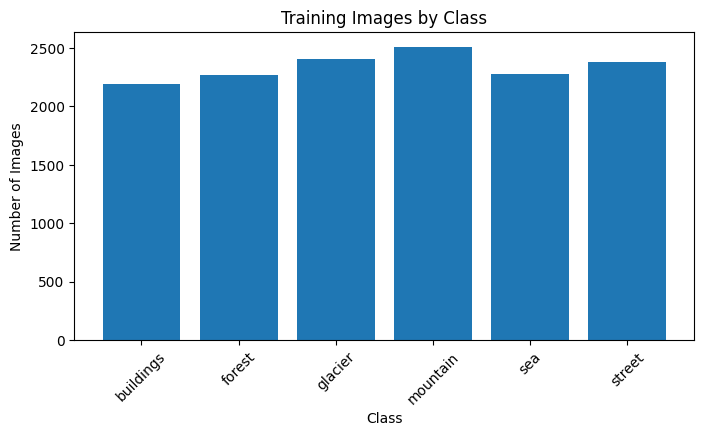

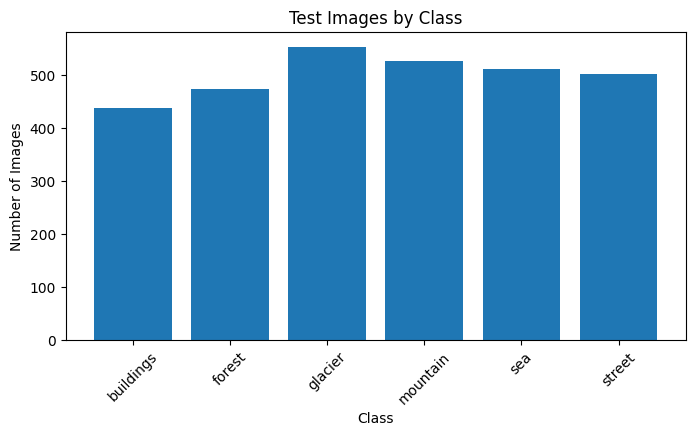

In [7]:
plt.figure(figsize=(8, 4))
plt.bar(train_counts["class"], train_counts["count"])
plt.title("Training Images by Class")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(8, 4))
plt.bar(test_counts["class"], test_counts["count"])
plt.title("Test Images by Class")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.show()

## Class Distribution

The class distribution shows how many images belong to each scene category.

The training set contains 14,034 images, while the test set contains 3,000 images.

The training class counts are:

- Buildings: 2,191
- Forest: 2,271
- Glacier: 2,404
- Mountain: 2,512
- Sea: 2,274
- Street: 2,382

The test class counts are:

- Buildings: 437
- Forest: 474
- Glacier: 553
- Mountain: 525
- Sea: 510
- Street: 501

The classes are fairly balanced. Mountain and glacier have slightly more images than buildings and forest, but the differences are not large enough to create a serious class imbalance problem.

Checking class distribution is important because strong imbalance can cause a CNN to perform well on common classes while performing poorly on underrepresented classes.

In [8]:
raw_train_dataset = datasets.ImageFolder(root=train_dir)

class_names = raw_train_dataset.classes
class_names

['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

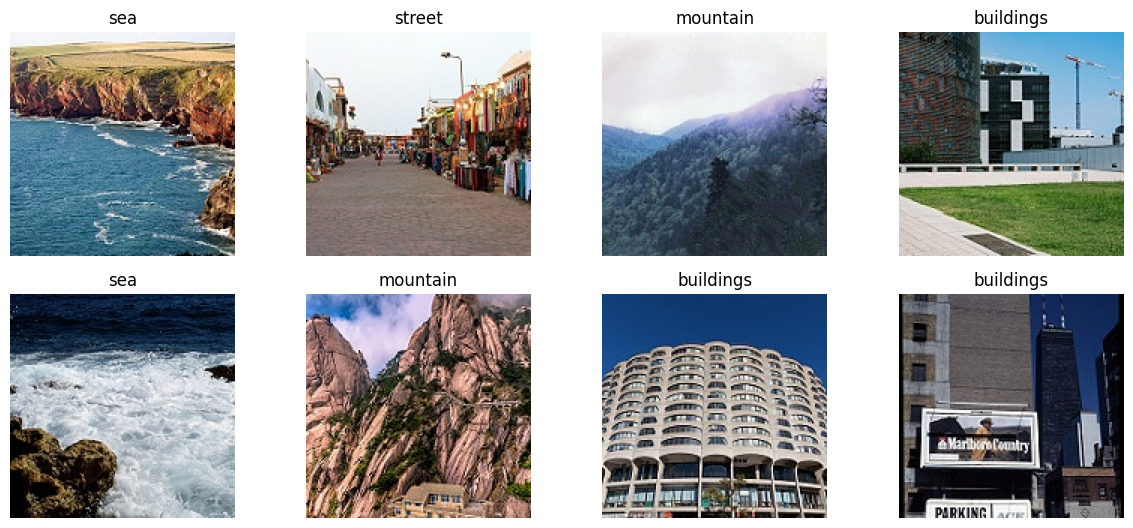

In [10]:
def show_sample_images(dataset, class_names, n_images=8):
    indices = random.sample(range(len(dataset)), n_images)
    
    plt.figure(figsize=(12, 8))
    
    for i, idx in enumerate(indices):
        image, label = dataset[idx]
        
        plt.subplot(3, 4, i + 1)
        plt.imshow(image)
        plt.title(class_names[label])
        plt.axis("off")
    
    plt.tight_layout()
    plt.show()

show_sample_images(raw_train_dataset, class_names)

## Sample Images

Sample images are displayed to understand what the CNN will learn from.

This step helps check that the dataset loaded correctly and that the class labels match the visual content.

The task is a multi-class image classification problem where the model must learn visual patterns such as buildings, trees, snow, mountains, water, and streets.

In [11]:
IMG_SIZE = 150
BATCH_SIZE = 64

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.15
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

eval_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

## Image Transforms and Augmentation

Image transforms prepare raw images for the CNN.

All images are resized to 150×150 pixels so that they have a consistent input shape.

The training transform includes basic data augmentation:

- Random horizontal flip
- Small random rotation
- Slight colour jitter

Data augmentation creates slightly different versions of training images. This helps the model generalize better instead of memorizing exact images.

The validation and test transforms do not use random augmentation. They only resize, convert to tensors, and normalize the images.

In [12]:
full_train_dataset_aug = datasets.ImageFolder(root=train_dir, transform=train_transforms)
full_train_dataset_eval = datasets.ImageFolder(root=train_dir, transform=eval_transforms)

test_dataset = datasets.ImageFolder(root=test_dir, transform=eval_transforms)

num_train = len(full_train_dataset_aug)
val_size = int(0.2 * num_train)
train_size = num_train - val_size

generator = torch.Generator().manual_seed(SEED)

train_subset_aug, val_subset_indices = random_split(
    range(num_train),
    [train_size, val_size],
    generator=generator
)

train_indices = train_subset_aug.indices
val_indices = val_subset_indices.indices

from torch.utils.data import Subset

train_dataset = Subset(full_train_dataset_aug, train_indices)
val_dataset = Subset(full_train_dataset_eval, val_indices)

print("Train size:", len(train_dataset))
print("Validation size:", len(val_dataset))
print("Test size:", len(test_dataset))
print("Classes:", full_train_dataset_aug.classes)

Train size: 11228
Validation size: 2806
Test size: 3000
Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [13]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

## Dataset Split

The training folder is split into a training subset and a validation subset.

The training subset is used to update the CNN weights.

The validation subset is used to monitor generalization during training.

The separate test set is kept untouched until final evaluation.

The training subset uses augmentation, while the validation and test sets use deterministic transforms. This ensures that validation and test results reflect real model performance rather than random augmented views.

In [14]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 9 * 9, 512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, num_classes)
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [15]:
num_classes = len(class_names)

model = SimpleCNN(num_classes=num_classes).to(device)

sample_batch, sample_labels = next(iter(train_loader))
sample_batch = sample_batch.to(device)

with torch.no_grad():
    sample_outputs = model(sample_batch)

print("Input batch shape:", sample_batch.shape)
print("Output batch shape:", sample_outputs.shape)

Input batch shape: torch.Size([64, 3, 150, 150])
Output batch shape: torch.Size([64, 6])


## Simple CNN Architecture

The first model is a custom Convolutional Neural Network.

A CNN learns visual features using convolutional layers.

The model contains:

- Convolutional layers for feature extraction
- Batch normalization for more stable training
- ReLU activations for non-linearity
- Max pooling for spatial downsampling
- Dropout to reduce overfitting
- Fully connected layers for classification

The final output layer has one logit for each class.

In [16]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    
    return epoch_loss, epoch_acc

In [18]:
def evaluate_model(model, dataloader, criterion, device):
    model.eval()
    
    running_loss = 0.0
    correct = 0
    total = 0
    
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    
    return epoch_loss, epoch_acc, np.array(all_preds), np.array(all_labels)

## Training Loop

PyTorch training usually requires a manual training loop.

For each batch:

1. Move images and labels to the device
2. Run a forward pass through the CNN
3. Calculate the loss
4. Clear old gradients
5. Backpropagate the loss
6. Update the model weights
7. Track loss and accuracy

The evaluation loop is similar, but it disables gradient calculation and does not update model weights.

In [20]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

EPOCHS = 10

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

best_val_acc = 0.0
best_model_state = None

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )
    
    val_loss, val_acc, _, _ = evaluate_model(
        model,
        val_loader,
        criterion,
        device
    )
    
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = model.state_dict()
    
    print(
        f"Epoch {epoch + 1}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

model.load_state_dict(best_model_state)
print("Best validation accuracy:", best_val_acc)

Epoch 1/10 | Train Loss: 1.0278 | Train Acc: 0.6340 | Val Loss: 0.7057 | Val Acc: 0.7463
Epoch 2/10 | Train Loss: 0.7520 | Train Acc: 0.7332 | Val Loss: 0.6024 | Val Acc: 0.7862
Epoch 3/10 | Train Loss: 0.6646 | Train Acc: 0.7610 | Val Loss: 0.6262 | Val Acc: 0.7915
Epoch 4/10 | Train Loss: 0.6207 | Train Acc: 0.7784 | Val Loss: 0.5204 | Val Acc: 0.8079
Epoch 5/10 | Train Loss: 0.5928 | Train Acc: 0.7895 | Val Loss: 0.5170 | Val Acc: 0.8272
Epoch 6/10 | Train Loss: 0.5621 | Train Acc: 0.8011 | Val Loss: 0.6097 | Val Acc: 0.7723
Epoch 7/10 | Train Loss: 0.5312 | Train Acc: 0.8114 | Val Loss: 0.4917 | Val Acc: 0.8204
Epoch 8/10 | Train Loss: 0.5185 | Train Acc: 0.8154 | Val Loss: 0.5102 | Val Acc: 0.8158
Epoch 9/10 | Train Loss: 0.5016 | Train Acc: 0.8205 | Val Loss: 0.5434 | Val Acc: 0.8072
Epoch 10/10 | Train Loss: 0.4772 | Train Acc: 0.8335 | Val Loss: 0.6306 | Val Acc: 0.7929
Best validation accuracy: 0.8271560940841055


## Training Results

The simple CNN was trained for 10 epochs.

The training accuracy improved from 0.6340 in epoch 1 to 0.8335 in epoch 10. This shows that the model learned useful visual patterns from the training images.

The best validation accuracy achieved by the simple CNN was 0.8272.

Validation accuracy improved during the early epochs, reaching its best value at epoch 5. After that, validation accuracy fluctuated and did not consistently improve, while training accuracy continued increasing.

This suggests mild overfitting. The model continued learning the training data, but the validation performance did not improve at the same rate.

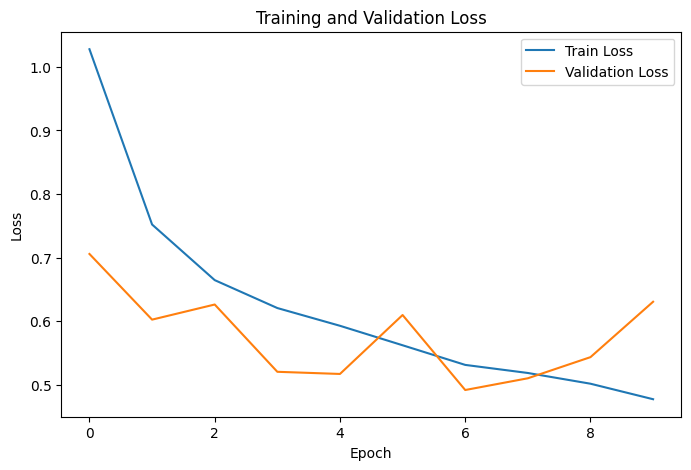

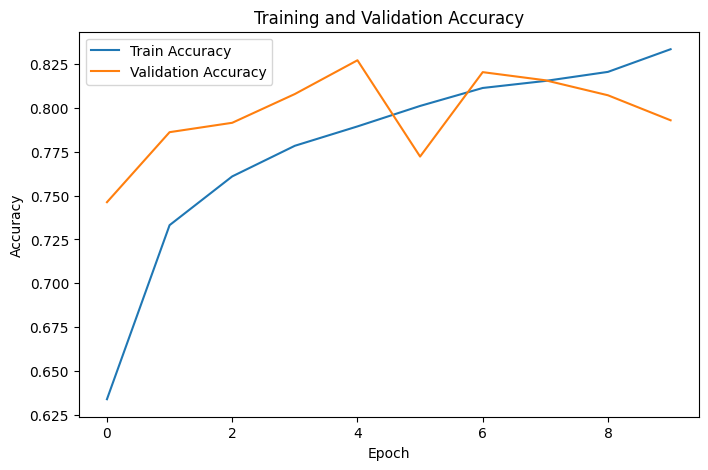

In [21]:
plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history["train_acc"], label="Train Accuracy")
plt.plot(history["val_acc"], label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

## Training Curves

Training curves show how the model changes over time.

If both training and validation accuracy are low, the model may be underfitting.

If training accuracy keeps improving but validation accuracy stops improving or decreases, the model may be overfitting.

If both curves improve together, the model is learning useful patterns and generalizing reasonably well.

In [22]:
test_loss, test_acc, test_preds, test_labels = evaluate_model(
    model,
    test_loader,
    criterion,
    device
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

Test Loss: 0.5899565237363179
Test Accuracy: 0.8093333333333333


In [23]:
print(classification_report(
    test_labels,
    test_preds,
    target_names=class_names,
    digits=4
))

              precision    recall  f1-score   support

   buildings     0.6343    0.9405    0.7576       437
      forest     0.9724    0.8903    0.9295       474
     glacier     0.8337    0.7884    0.8104       553
    mountain     0.8928    0.6343    0.7416       525
         sea     0.7714    0.9196    0.8390       510
      street     0.8623    0.7126    0.7803       501

    accuracy                         0.8093      3000
   macro avg     0.8278    0.8143    0.8098      3000
weighted avg     0.8311    0.8093    0.8093      3000



In [24]:
cm = confusion_matrix(test_labels, test_preds)

cm_df = pd.DataFrame(
    cm,
    index=class_names,
    columns=class_names
)

cm_df

,buildings,forest,glacier,mountain,sea,street
buildings,411,3,2,0,1,20
forest,16,422,0,2,3,31
glacier,28,4,436,30,50,5
mountain,41,2,73,333,76,0
sea,23,1,9,7,469,1
street,129,2,3,1,9,357


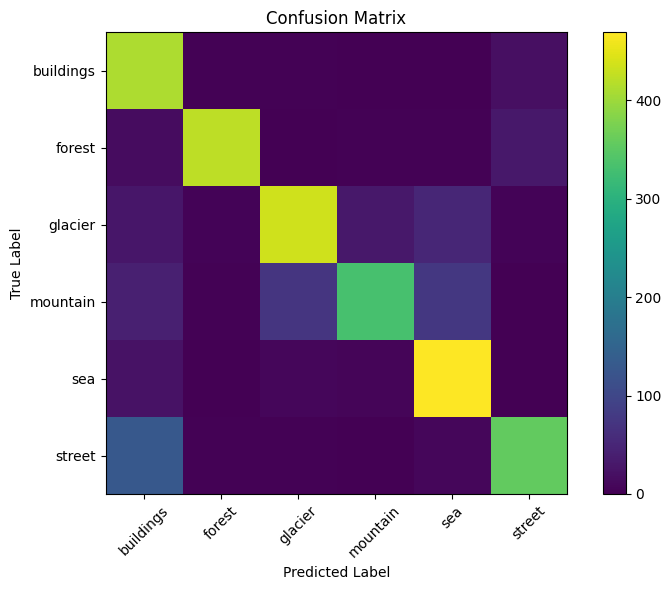

In [25]:
plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

## Test Set Evaluation

The simple CNN is evaluated on the separate test set.

The simple CNN achieved a test loss of 0.5900 and a test accuracy of 0.8093.

The classification report shows that the model performed very strongly on forest, with an F1-score of 0.9295. It also performed reasonably well on sea and glacier.

The weaker classes were buildings, mountain, and street. Buildings had high recall but lower precision, meaning the model predicted buildings too often. Mountain had lower recall, meaning many mountain images were misclassified as other classes.

The confusion matrix shows several major confusion patterns:

- Street images were often predicted as buildings.
- Mountain images were often predicted as glacier or sea.
- Glacier images were sometimes predicted as sea or mountain.
- Buildings and streets were frequently confused.

This is important because overall accuracy alone does not show which scene categories are difficult for the model.

In [26]:
def unnormalize_image(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    
    image = tensor.cpu() * std + mean
    image = image.clamp(0, 1)
    
    return image.permute(1, 2, 0).numpy()

In [27]:
def collect_predictions(model, dataloader, device):
    model.eval()
    
    records = []
    
    with torch.no_grad():
        for images, labels in dataloader:
            images_device = images.to(device)
            outputs = model(images_device)
            probs = torch.softmax(outputs, dim=1)
            preds = outputs.argmax(dim=1).cpu()
            
            for i in range(images.size(0)):
                records.append({
                    "image": images[i],
                    "true_label": labels[i].item(),
                    "pred_label": preds[i].item(),
                    "confidence": probs[i, preds[i]].cpu().item()
                })
    
    return records

test_records = collect_predictions(model, test_loader, device)

misclassified = [
    record for record in test_records
    if record["true_label"] != record["pred_label"]
]

print("Number of misclassified images:", len(misclassified))

Number of misclassified images: 572


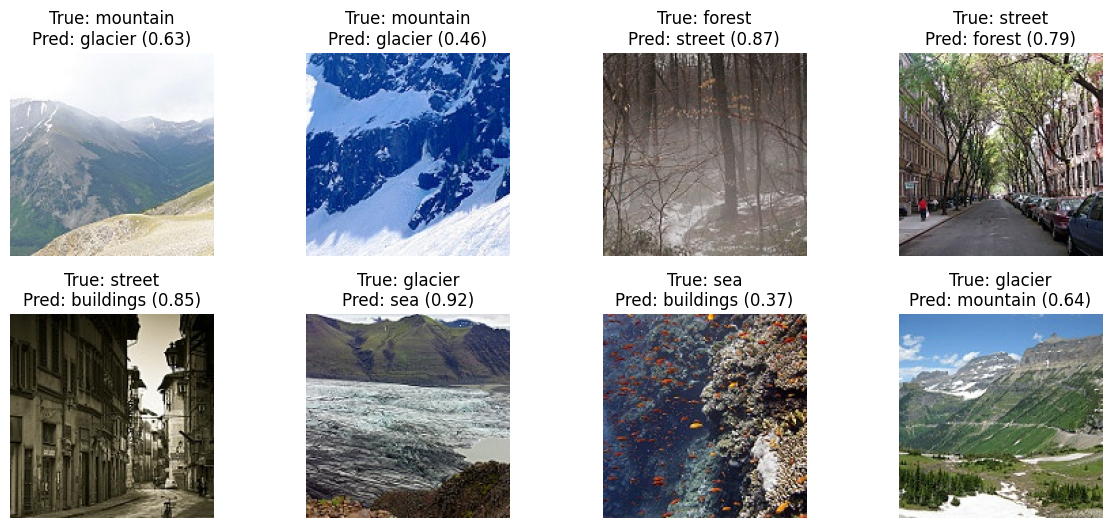

In [31]:
def show_misclassified_examples(misclassified, class_names, n=12):
    examples = random.sample(misclassified, min(n, len(misclassified)))
    
    plt.figure(figsize=(12, 8))
    
    for i, record in enumerate(examples):
        image = unnormalize_image(record["image"])
        true_name = class_names[record["true_label"]]
        pred_name = class_names[record["pred_label"]]
        conf = record["confidence"]
        
        plt.subplot(3, 4, i + 1)
        plt.imshow(image)
        plt.title(f"True: {true_name}\nPred: {pred_name} ({conf:.2f})")
        plt.axis("off")
    
    plt.tight_layout()
    plt.show()

show_misclassified_examples(misclassified, class_names, n=8)

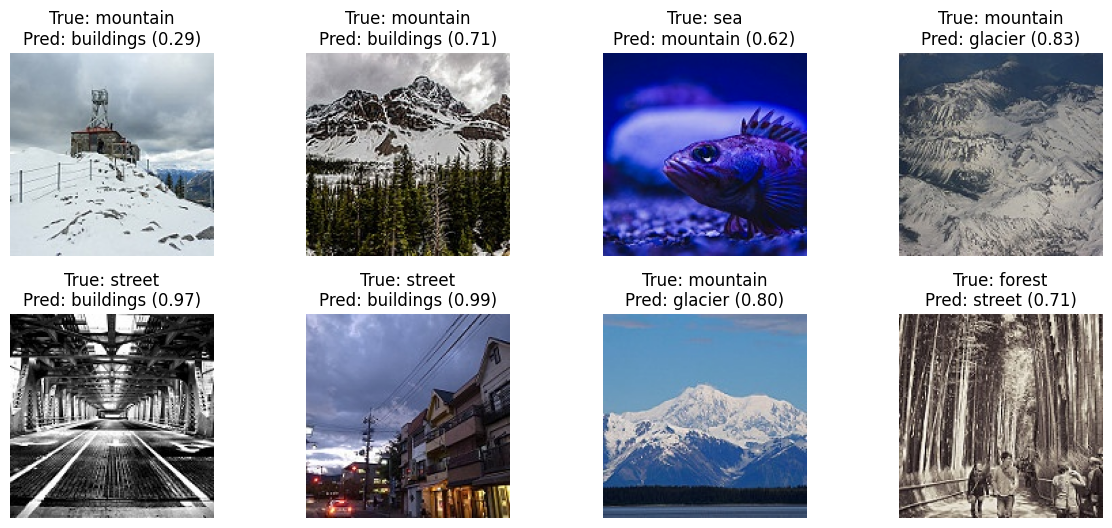

In [32]:
high_conf_mistakes = sorted(
    misclassified,
    key=lambda x: x["confidence"],
    reverse=True
)

show_misclassified_examples(high_conf_mistakes, class_names, n=8)

## Misclassification Analysis

The simple CNN misclassified 572 out of 3,000 test images.

Misclassification analysis helps explain where the CNN struggles.

The confusion matrix shows that several mistakes come from visually overlapping classes. For example, mountain, glacier, and sea can share similar natural landscape features. Buildings and streets can also appear together in the same image, making them difficult to separate.

The largest confusion pattern was street images being predicted as buildings. This makes sense because many street scenes contain buildings, roads, and urban structures.

Mountain images were also commonly confused with glacier and sea, likely because these classes can contain similar colours, textures, horizons, and outdoor scenery.

High-confidence mistakes are especially useful to inspect because they show cases where the model was wrong but very certain. These mistakes can reveal ambiguous images, noisy labels, or visual patterns the model has learned incorrectly.

In [34]:
class ImprovedCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        
        self.features = nn.Sequential(
            self.conv_block(3, 32),
            self.conv_block(32, 64),
            self.conv_block(64, 128),
            self.conv_block(128, 256),
            self.conv_block(256, 512),
        )
        
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
    
    def conv_block(self, in_channels, out_channels):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.classifier(x)
        return x

In [35]:
improved_model = ImprovedCNN(num_classes=num_classes).to(device)

with torch.no_grad():
    sample_outputs = improved_model(sample_batch)

print("Improved model output shape:", sample_outputs.shape)

Improved model output shape: torch.Size([64, 6])


## Improved CNN Architecture

The improved CNN uses deeper convolutional blocks.

Each block contains two convolutional layers before max pooling. This allows the model to learn richer local visual features before reducing spatial resolution.

The model also uses adaptive average pooling. This converts the final feature maps into a fixed-size representation, making the classifier less dependent on the exact spatial dimensions.

This architecture is still small enough for a learning notebook but is more flexible than the first simple CNN.

In [36]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    improved_model.parameters(),
    lr=5e-4,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)

EPOCHS = 10

improved_history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

best_improved_val_acc = 0.0
best_improved_state = None

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(
        improved_model,
        train_loader,
        criterion,
        optimizer,
        device
    )
    
    val_loss, val_acc, _, _ = evaluate_model(
        improved_model,
        val_loader,
        criterion,
        device
    )
    
    scheduler.step(val_acc)
    
    improved_history["train_loss"].append(train_loss)
    improved_history["train_acc"].append(train_acc)
    improved_history["val_loss"].append(val_loss)
    improved_history["val_acc"].append(val_acc)
    
    if val_acc > best_improved_val_acc:
        best_improved_val_acc = val_acc
        best_improved_state = improved_model.state_dict()
    
    current_lr = optimizer.param_groups[0]["lr"]
    
    print(
        f"Epoch {epoch + 1}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f} | "
        f"LR: {current_lr:.6f}"
    )

improved_model.load_state_dict(best_improved_state)
print("Best improved validation accuracy:", best_improved_val_acc)

Epoch 1/10 | Train Loss: 0.8809 | Train Acc: 0.6509 | Val Loss: 1.2084 | Val Acc: 0.5966 | LR: 0.000500
Epoch 2/10 | Train Loss: 0.6324 | Train Acc: 0.7679 | Val Loss: 0.6542 | Val Acc: 0.7630 | LR: 0.000500
Epoch 3/10 | Train Loss: 0.5380 | Train Acc: 0.8077 | Val Loss: 0.5479 | Val Acc: 0.7983 | LR: 0.000500
Epoch 4/10 | Train Loss: 0.5122 | Train Acc: 0.8182 | Val Loss: 0.4692 | Val Acc: 0.8293 | LR: 0.000500
Epoch 5/10 | Train Loss: 0.4597 | Train Acc: 0.8375 | Val Loss: 0.4409 | Val Acc: 0.8421 | LR: 0.000500
Epoch 6/10 | Train Loss: 0.4198 | Train Acc: 0.8496 | Val Loss: 0.4071 | Val Acc: 0.8528 | LR: 0.000500
Epoch 7/10 | Train Loss: 0.4134 | Train Acc: 0.8555 | Val Loss: 0.4639 | Val Acc: 0.8343 | LR: 0.000500
Epoch 8/10 | Train Loss: 0.3807 | Train Acc: 0.8654 | Val Loss: 0.5067 | Val Acc: 0.8289 | LR: 0.000500
Epoch 9/10 | Train Loss: 0.3740 | Train Acc: 0.8688 | Val Loss: 0.3855 | Val Acc: 0.8628 | LR: 0.000500
Epoch 10/10 | Train Loss: 0.3653 | Train Acc: 0.8741 | Val Loss:

## Improved CNN Training Results

The improved CNN was trained for 10 epochs using a smaller learning rate and a learning-rate scheduler.

The training accuracy improved from 0.6509 in epoch 1 to 0.8741 in epoch 10. Validation accuracy improved from 0.5966 to a best value of 0.8628.

The best validation accuracy achieved by the improved CNN was 0.8628.

Compared with the simple CNN's best validation accuracy of 0.8272, the improved CNN achieved stronger validation performance.

This suggests that the deeper convolutional blocks and adaptive average pooling helped the model learn better image features and generalize more effectively.

In [37]:
improved_test_loss, improved_test_acc, improved_test_preds, improved_test_labels = evaluate_model(
    improved_model,
    test_loader,
    criterion,
    device
)

print("Improved Test Loss:", improved_test_loss)
print("Improved Test Accuracy:", improved_test_acc)

Improved Test Loss: 0.4135281761487325
Improved Test Accuracy: 0.856


In [38]:
print(classification_report(
    improved_test_labels,
    improved_test_preds,
    target_names=class_names,
    digits=4
))

              precision    recall  f1-score   support

   buildings     0.8082    0.9062    0.8544       437
      forest     0.9975    0.8418    0.9130       474
     glacier     0.8385    0.8354    0.8370       553
    mountain     0.8320    0.8114    0.8216       525
         sea     0.8872    0.8941    0.8906       510
      street     0.8049    0.8563    0.8298       501

    accuracy                         0.8560      3000
   macro avg     0.8614    0.8575    0.8577      3000
weighted avg     0.8607    0.8560    0.8568      3000



In [39]:
improved_cm = confusion_matrix(improved_test_labels, improved_test_preds)

improved_cm_df = pd.DataFrame(
    improved_cm,
    index=class_names,
    columns=class_names
)

improved_cm_df

,buildings,forest,glacier,mountain,sea,street
buildings,396,0,2,1,5,33
forest,6,399,7,2,5,55
glacier,7,0,462,48,30,6
mountain,13,0,70,426,12,4
sea,6,1,10,31,456,6
street,62,0,0,4,6,429


## Improved CNN Test Evaluation

The improved CNN is evaluated on the same untouched test set.

The improved CNN achieved a test loss of 0.4135 and a test accuracy of 0.8560.

This is a clear improvement over the simple CNN, which achieved a test accuracy of 0.8093.

The improved model performed strongly across most classes. The highest F1-scores were for forest and sea, with F1-scores of 0.9130 and 0.8906.

The weaker classes were mountain, street, and glacier, although their performance was still reasonable. The confusion matrix shows that the improved CNN still confused:

- Street with buildings
- Mountain with glacier
- Glacier with mountain or sea
- Forest with street

Overall, the improved CNN generalized better than the simple CNN. The deeper architecture, adaptive pooling, and more stable training setup improved both validation accuracy and test accuracy.

In [40]:
comparison_df = pd.DataFrame([
    {
        "Model": "Simple CNN",
        "Best Val Accuracy": best_val_acc,
        "Test Accuracy": test_acc,
        "Test Loss": test_loss
    },
    {
        "Model": "Improved CNN",
        "Best Val Accuracy": best_improved_val_acc,
        "Test Accuracy": improved_test_acc,
        "Test Loss": improved_test_loss
    }
])

comparison_df

,Model,Best Val Accuracy,Test Accuracy,Test Loss
0,Simple CNN,0.827156,0.809333,0.589957
1,Improved CNN,0.862794,0.856000,0.413528


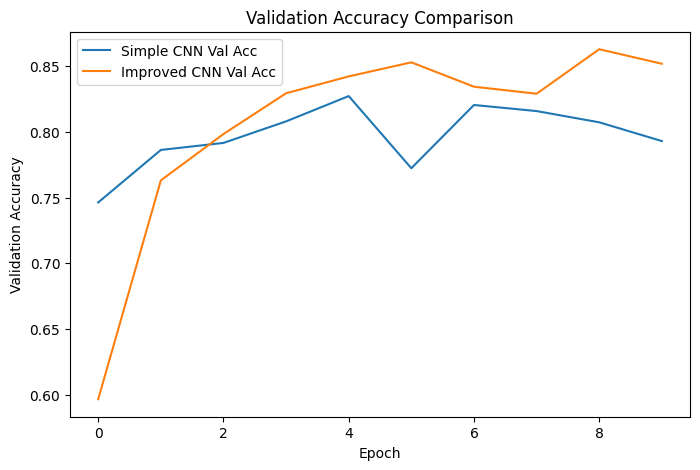

In [41]:
plt.figure(figsize=(8, 5))
plt.plot(history["val_acc"], label="Simple CNN Val Acc")
plt.plot(improved_history["val_acc"], label="Improved CNN Val Acc")
plt.title("Validation Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.show()

## Model Comparison

The simple CNN and improved CNN are compared using validation accuracy, test accuracy, and test loss.

The simple CNN achieved:

- Best validation accuracy: 0.8272
- Test accuracy: 0.8093
- Test loss: 0.5900

The improved CNN achieved:

- Best validation accuracy: 0.8628
- Test accuracy: 0.8560
- Test loss: 0.4135

The improved CNN was the better-performing model.

It achieved higher validation accuracy, higher test accuracy, and lower test loss. This shows that the improved architecture learned stronger visual features and generalized better to unseen test images.

The improvement is meaningful because test accuracy increased by about 4.67 percentage points, from 80.93% to 85.60%.